In [2]:
#libraries
import torch        #Tensorflow/Keras nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import alexnet,AlexNet_Weights

In [5]:
#load pretrained
Weights=AlexNet_Weights.IMAGENET1K_V1  #weights pretrained on ImageNet-1K.
model = alexnet(weights=Weights)
model.eval()         # evaluation mode_predit
print(model)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 152MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [51]:
preprocess=Weights.transforms()

In [52]:
from google.colab import files
uploaded=files.upload()

filename=list(uploaded.keys())[0]
print("Uploaded file: ",filename)

Saving cat_damaged.png to cat_damaged (2).png
Uploaded file:  cat_damaged (2).png


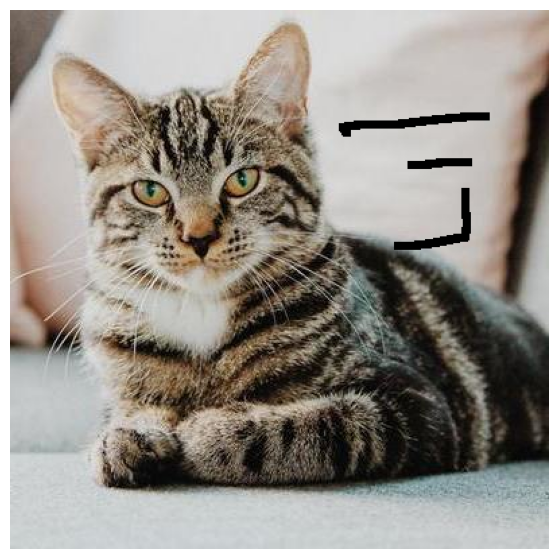

In [44]:
img=Image.open(filename).convert("RGB")

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.axis("off")
plt.show()

In [45]:
#preprocess_ pretrained alexnet

input_tensor=preprocess(img)       #nor PT
input_batch=input_tensor.unsqueeze(0)
print("Input shape:", input_batch.shape)

Input shape: torch.Size([1, 3, 224, 224])


In [46]:
#prediction
with torch.no_grad():              #no gradient cal
      output=model(input_batch)
probabilities=torch.nn.functional.softmax(
    output[0],                    #1i
    dim=0
)

In [47]:
#
top5_prob,top5_catid=torch.topk(
    probabilities, 5
)

In [48]:
categories=Weights.meta["categories"]
print("\n Top 5 Predictions:")
for i in range(top5_prob.size(0)):
      class_id=top5_catid[i].item()        #PT value to Python no
      probability=top5_prob[i].item()
      print(
        f"{i+1}. {categories[class_id]} : "
         f"{probability * 100:.2f}%"
      )


 Top 5 Predictions:
1. tabby : 89.36%
2. tiger cat : 5.23%
3. Egyptian cat : 1.42%
4. lens cap : 0.68%
5. swab : 0.42%


In [49]:
predicted_class = top5_catid[0].item()
predicted_label = categories[predicted_class]
predicted_probability = top5_prob[0].item()
print("\nFinal Prediction:")
print( predicted_label,
          ":",
        f"{predicted_probability * 100:.2f}%"
         )


Final Prediction:
tabby : 89.36%


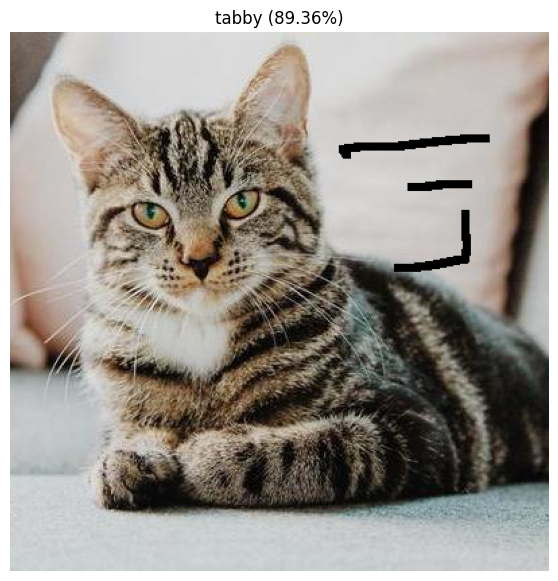

In [50]:
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.title(
    f"{predicted_label} "
     f"({predicted_probability * 100:.2f}%)"
 )
plt.axis("off")
plt.show()